# Imports

In [1]:
import keras
import numpy as np
import gymnasium as gym
import tensorflow as tf
import tqdm.notebook as tqdm
import matplotlib.pyplot as plt
import os, time
from collections import deque


In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
              tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)


# Environment

Create the [environment](https://gymnasium.farama.org/environments/box2d/bipedal_walker/).

In [3]:
def make_env(seed: int | None = None) -> gym.Env:
    """Build a single BipedalWalker environment (continuous, non-hardcore).

    Note: we do NOT wrap with gym.wrappers.ClipAction — that wrapper rewrites
    action_space.high to +inf, which silently breaks any code that reads the bounds.
    We clip actions manually before each env.step() instead.
    """
    env = gym.make("BipedalWalker-v3")
    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
    return env

env = make_env(seed=42)

obs_dim  = env.observation_space.shape[0]   # 24
act_dim  = env.action_space.shape[0]        #  4
act_high = float(env.action_space.high[0])  #  1.0
act_low  = float(env.action_space.low[0])   # -1.0

assert np.isfinite(act_high) and np.isfinite(act_low), \
    f"Action bounds must be finite, got [{act_low}, {act_high}]"

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"obs_dim={obs_dim}, act_dim={act_dim}, action range=[{act_low}, {act_high}]")


Observation space: Box([-3.1415927 -5.        -5.        -5.        -3.1415927 -5.
 -3.1415927 -5.        -0.        -3.1415927 -5.        -3.1415927
 -5.        -0.        -1.        -1.        -1.        -1.
 -1.        -1.        -1.        -1.        -1.        -1.       ], [3.1415927 5.        5.        5.        3.1415927 5.        3.1415927
 5.        5.        3.1415927 5.        3.1415927 5.        5.
 1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.       ], (24,), float32)
Action space:      Box(-1.0, 1.0, (4,), float32)
obs_dim=24, act_dim=4, action range=[-1.0, 1.0]


C:\Users\maxim\anaconda3\envs\ocrlab\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


# Replay Buffer

Create a replay buffer to hold game history

In [4]:
class ReplayBuffer:

    def __init__(self, max_size: int, observation_space: gym.spaces.Space, action_space: gym.spaces.Space, seed: int | None = None):
        """Stores the replay history with a maximum of `max_size` entries, removing old entries as needed.

        Parameters:
            max_size: maximal number of entries to keep
            observation_space: specification of the observation space
            action_space: specification of the action space
            seed: seed to initialize the internal random number generator for reproducibility"""
        self.max_size = int(max_size)
        self.rng = np.random.default_rng(seed)
        self.ptr = 0
        self.size = 0

        obs_shape = observation_space.shape
        act_shape = action_space.shape

        self.current_observations = np.zeros((self.max_size, *obs_shape), dtype=np.float32)
        self.actions              = np.zeros((self.max_size, *act_shape), dtype=np.float32)
        self.rewards              = np.zeros((self.max_size,),            dtype=np.float32)
        self.next_observations    = np.zeros((self.max_size, *obs_shape), dtype=np.float32)
        self.dones                = np.zeros((self.max_size,),            dtype=np.float32)

    def add(self, current_observations: np.ndarray, actions: np.ndarray, rewards: np.ndarray,
            next_observations: np.ndarray, dones: np.ndarray) -> None:
        """Add new entries (one or many) to the buffer."""
        current_observations = np.atleast_2d(current_observations)
        actions              = np.atleast_2d(actions)
        rewards              = np.atleast_1d(rewards).astype(np.float32)
        next_observations    = np.atleast_2d(next_observations)
        dones                = np.atleast_1d(dones).astype(np.float32)

        batch = current_observations.shape[0]
        for i in range(batch):
            idx = self.ptr
            self.current_observations[idx] = current_observations[i]
            self.actions[idx]              = actions[i]
            self.rewards[idx]              = rewards[i]
            self.next_observations[idx]    = next_observations[i]
            self.dones[idx]                = dones[i]
            self.ptr  = (self.ptr + 1) % self.max_size
            self.size = min(self.size + 1, self.max_size)

    def sample(self, n_samples: int, replace: bool = True) -> tuple[np.ndarray, ...]:
        """Randomly samples `n_samples` transitions."""
        if not replace and n_samples > self.size:
            raise ValueError(f"Cannot sample {n_samples} without replacement from buffer of size {self.size}")
        indices = self.rng.choice(self.size, size=n_samples, replace=replace)
        return self[indices]

    def clear(self) -> None:
        self.ptr = 0
        self.size = 0

    def __getitem__(self, index):
        return (
            self.current_observations[index],
            self.actions[index],
            self.rewards[index],
            self.next_observations[index],
            self.dones[index],
        )

    def __len__(self) -> int:
        return self.size


# Model

Implement your model.

Используем архитектуру DDPG с LayerNormalization - она заметно стабилизирует обучение на BipedalWalker, где компоненты observation имеют разные масштабы (угол корпуса vs. скорости vs. лидарные замеры).

- **Policy (Actor)**: `obs → Dense(256) → LayerNorm → ReLU → Dense(256) → LayerNorm → ReLU → Dense(act_dim, tanh) → scale`
- **Q-function (Critic)**: `[obs, act] → Dense(256) → LayerNorm → ReLU → Dense(256) → LayerNorm → ReLU → Dense(1)`

In [5]:
@keras.saving.register_keras_serializable()
class ScaleLayer(keras.layers.Layer):
    """Scales tanh output to the action range."""
    def __init__(self, scale: float, **kwargs):
        super().__init__(**kwargs)
        self.scale = float(scale)

    def call(self, inputs):
        return inputs * self.scale

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"scale": self.scale})
        return cfg


def build_policy_model(obs_dim: int, act_dim: int, act_high: float) -> keras.Model:
    """Actor network: observation -> deterministic action in [-act_high, act_high]."""
    obs_input = keras.Input(shape=(obs_dim,), name="observation")
    x = keras.layers.Dense(256)(obs_input)
    x = keras.layers.LayerNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.Dense(256)(x)
    x = keras.layers.LayerNormalization()(x)
    x = keras.layers.ReLU()(x)
    # Small init on the final layer is a common DDPG trick - keeps initial actions near zero.
    raw = keras.layers.Dense(
        act_dim,
        activation="tanh",
        kernel_initializer=keras.initializers.RandomUniform(-3e-3, 3e-3),
    )(x)
    actions = ScaleLayer(act_high, name="scale")(raw)
    return keras.Model(inputs=obs_input, outputs=actions, name="policy")


def build_q_model(obs_dim: int, act_dim: int) -> keras.Model:
    """Critic network: (observation, action) -> scalar Q-value."""
    obs_input = keras.Input(shape=(obs_dim,), name="observation")
    act_input = keras.Input(shape=(act_dim,), name="action")
    x = keras.layers.Concatenate()([obs_input, act_input])
    x = keras.layers.Dense(256)(x)
    x = keras.layers.LayerNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.Dense(256)(x)
    x = keras.layers.LayerNormalization()(x)
    x = keras.layers.ReLU()(x)
    q_value = keras.layers.Dense(
        1,
        kernel_initializer=keras.initializers.RandomUniform(-3e-3, 3e-3),
    )(x)
    return keras.Model(inputs=[obs_input, act_input], outputs=q_value, name="q_function")


def clone_model(source: keras.Model) -> keras.Model:
    """Return a hard copy of `source` with identical weights."""
    clone = keras.models.clone_model(source)
    clone.set_weights(source.get_weights())
    return clone


def soft_update(target: keras.Model, source: keras.Model, tau: float) -> None:
    """Polyak averaging: target = tau * source + (1 - tau) * target."""
    for t_w, s_w in zip(target.weights, source.weights):
        t_w.assign(tau * s_w + (1.0 - tau) * t_w)


# Sampler (exploration noise)

Вместо OU-шума используем Gaussian noise с линейно убывающей sigma. Для непрерывного управления с 4 независимыми моторами BipedalWalker это работает лучше (нет искусственной корреляции, которая мешает обучать двусторонние движения ног).

In [6]:
class Sampler:
    """Gaussian exploration noise with linearly decaying standard deviation."""

    def __init__(self, act_dim: int, sigma: float = 0.2, seed: int | None = None):
        self.act_dim = act_dim
        self.sigma = float(sigma)
        self.rng = np.random.default_rng(seed)

    def __call__(self) -> np.ndarray:
        return self.rng.normal(0.0, self.sigma, size=self.act_dim).astype(np.float32)

    def reset(self) -> None:
        # Gaussian noise is i.i.d. - nothing to reset, but we keep the method for API symmetry.
        pass

    def set_sigma(self, sigma: float) -> None:
        self.sigma = float(sigma)


# Play the game

Interact with the environment and store transitions in the replay buffer.

**Важно**: `terminated` и `truncated` хранятся раздельно. В replay buffer в поле `done` идёт **только `terminated`** (реальное падение), а не `truncated` (истечение таймлимита). Это критично для корректного bootstrap в уравнении Беллмана — см. раздел Loss.

In [7]:
def play_game(
    model: keras.Model,
    buffer: ReplayBuffer,
    env: gym.Env,
    steps: int,
    sampler: "Sampler",
    observations: np.ndarray | None = None,
    one_episode: bool = False,
    random_policy: bool = False,
) -> np.ndarray:
    """Plays the environment `env` using model `model` for a total of `steps` steps.

    Arguments:
        model:          actor (policy) model
        buffer:         replay buffer to append transitions to
        env:            gym environment
        steps:          number of environment steps to record (upper bound)
        sampler:        exploration noise sampler
        observations:   optional initial observation; if None, env is reset
        one_episode:    stop as soon as the current episode ends
        random_policy:  if True, ignore `model` and sample actions uniformly (warmup)

    Returns:
        the last observation seen (for continuing collection later)
    """
    if observations is None:
        observations, _ = env.reset()

    for _ in range(steps):
        if random_policy:
            action = env.action_space.sample()
        else:
            obs_batch = np.expand_dims(observations, axis=0).astype(np.float32)
            mean_action = model(obs_batch, training=False).numpy()[0]
            action = np.clip(mean_action + sampler(), act_low, act_high)

        next_observations, reward, terminated, truncated, _ = env.step(action)

        # CRUCIAL: only `terminated` means "no bootstrap". `truncated` = time limit, the value
        # of the next state is still meaningful, so we must NOT zero-out the bootstrap for it.
        store_done = float(terminated)

        buffer.add(observations, action, np.array([reward]),
                   next_observations, np.array([store_done]))

        if terminated or truncated:
            if one_episode:
                return next_observations
            observations, _ = env.reset()
            sampler.reset()
        else:
            observations = next_observations

    return observations


# Loss

Implement DDPG loss.

**Одна аккуратная модификация лосса**: добавляем clipped noise к действию target-политики в Bellman-таргете (target policy smoothing). Формально это всё ещё DDPG-лосс на single critic, но такое сглаживание почти полностью устраняет переоценку Q и не даёт политике эксплуатировать острые пики Q-функции — именно этот эффект порождает «прыжок на одной ноге».

$$y = r + \gamma \cdot (1 - d) \cdot Q_{\text{targ}}(s', \; \text{clip}(\mu_{\text{targ}}(s') + \epsilon, \, -1, 1))$$
$$\epsilon \sim \text{clip}(\mathcal{N}(0, \sigma_{\text{target}}), \, -c, \, c)$$

Критик минимизирует $\text{MSE}(Q(s, a), y)$, актор — $-\mathbb{E}[Q(s, \mu(s))]$.

In [8]:
# Target policy smoothing parameters (DDPG-compatible: still one critic).
TARGET_NOISE_STD  = 0.2
TARGET_NOISE_CLIP = 0.5


def ddpg_loss(
    current_observation: keras.KerasTensor,
    action: keras.KerasTensor,
    reward: keras.KerasTensor,
    next_observation: keras.KerasTensor,
    done: keras.KerasTensor,
    q_model: keras.Model,
    policy_model: keras.Model,
    target_q_model: keras.Model,
    target_policy_model: keras.Model,
    gamma: float,
) -> tuple[keras.KerasTensor, keras.KerasTensor]:
    """Computes Deep Deterministic Policy Gradient losses (critic + actor)."""

    # ---------- Critic target (stop-gradient) ----------
    next_actions = target_policy_model(next_observation, training=False)
    # Target policy smoothing: add clipped Gaussian noise to the target action.
    noise = tf.clip_by_value(
        tf.random.normal(tf.shape(next_actions), stddev=TARGET_NOISE_STD),
        -TARGET_NOISE_CLIP, TARGET_NOISE_CLIP,
    )
    next_actions = tf.clip_by_value(next_actions + noise, -1.0, 1.0)

    target_q = target_q_model([next_observation, next_actions], training=False)
    target_q = tf.squeeze(target_q, axis=-1)  # [B]

    y = reward + gamma * (1.0 - done) * target_q       # [B]
    y = tf.stop_gradient(y)

    # ---------- Critic loss (MSE Bellman residual) ----------
    current_q = q_model([current_observation, action], training=True)
    current_q = tf.squeeze(current_q, axis=-1)          # [B]
    q_loss = tf.reduce_mean(tf.square(current_q - y))

    # ---------- Actor loss (deterministic policy gradient) ----------
    predicted_actions = policy_model(current_observation, training=True)
    # training=False here avoids touching critic's LayerNorm running stats from the actor path.
    q_for_policy = q_model([current_observation, predicted_actions], training=False)
    policy_loss = -tf.reduce_mean(q_for_policy)

    return q_loss, policy_loss

# Training

Create models, replay buffers, optimizers, noise schedule, training loop, periodic evaluation.

**Hyperparameters chosen for BipedalWalker-v3**:
- `BUFFER_SIZE = 1M`, `BATCH_SIZE = 256`, `GAMMA = 0.99`, `TAU = 0.005`
- Actor LR = 1e-4, Critic LR = 1e-3, Adam
- `WARMUP_STEPS = 25_000` uniform-random actions to fill the buffer with diverse data
- Gaussian exploration sigma decays linearly from 0.3 → 0.05 over 500k steps
- Global-norm gradient clipping at 5.0 (stabilizes training against the −100 fall spike)
- Evaluation every 10k steps, best policy checkpointed

In [9]:
# ==================== Hyperparameters ====================
BUFFER_SIZE       = 1_000_000
BATCH_SIZE        = 256
GAMMA             = 0.99
TAU               = 0.005
LR_ACTOR          = 1e-4
LR_CRITIC         = 1e-3
WARMUP_STEPS      = 25_000
TOTAL_STEPS       = 2_000_000
TRAIN_EVERY       = 1
EVAL_EVERY        = 10_000
EVAL_EPISODES     = 5
GRAD_CLIP_NORM    = 5.0
SIGMA_START       = 0.3
SIGMA_END         = 0.05
SIGMA_DECAY_STEPS = 500_000
SEED              = 123

# ==================== Build everything ====================
tf.random.set_seed(SEED)
np.random.seed(SEED)

policy_model         = build_policy_model(obs_dim, act_dim, act_high)
q_model              = build_q_model(obs_dim, act_dim)
target_policy_model  = clone_model(policy_model)
target_q_model       = clone_model(q_model)

actor_optimizer  = keras.optimizers.Adam(learning_rate=LR_ACTOR, clipnorm=GRAD_CLIP_NORM)
critic_optimizer = keras.optimizers.Adam(learning_rate=LR_CRITIC, clipnorm=GRAD_CLIP_NORM)

buffer  = ReplayBuffer(BUFFER_SIZE, env.observation_space, env.action_space, seed=SEED)
sampler = Sampler(act_dim, sigma=SIGMA_START, seed=SEED)

policy_model.summary()
q_model.summary()


Model: "policy"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ observation (InputLayer)             │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │           6,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization                  │ (None, 256)                 │             512 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization_1                │ (None, 256)                 │             512 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │           1,028 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ scale (ScaleLayer)                   │ (None, 4)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,244 (290.02 KB)

 Trainable params: 74,244 (290.02 KB)

 Non-trainable params: 0 (0.00 B)

Model: "q_function"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ observation (InputLayer)      │ (None, 24)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ action (InputLayer)           │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 28)                │               0 │ observation[0][0],         │
│                               │                           │                 │ action[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 256)               │           7,424 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_2         │ (None, 256)               │             512 │ dense_3[0][0]              │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_2 (ReLU)                │ (None, 256)               │               0 │ layer_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 256)               │          65,792 │ re_lu_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_3         │ (None, 256)               │             512 │ dense_4[0][0]              │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_3 (ReLU)                │ (None, 256)               │               0 │ layer_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 1)                 │             257 │ re_lu_3[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
@tf.function # что делает эта функция?
def train_step(obs, act, rew, next_obs, done):
    """One gradient update on both critic and actor using the ddpg_loss."""
    # Single forward pass graph — both losses computed from a persistent tape.
    with tf.GradientTape(persistent=True) as tape:
        q_loss, p_loss = ddpg_loss(
            obs, act, rew, next_obs, done,
            q_model, policy_model,
            target_q_model, target_policy_model,
            GAMMA,
        )

    # Critic step
    q_grads = tape.gradient(q_loss, q_model.trainable_variables)
    critic_optimizer.apply_gradients(zip(q_grads, q_model.trainable_variables))

    # Actor step — only policy_model vars receive updates.
    p_grads = tape.gradient(p_loss, policy_model.trainable_variables)
    actor_optimizer.apply_gradients(zip(p_grads, policy_model.trainable_variables))

    del tape
    return q_loss, p_loss

In [11]:
def evaluate(policy: keras.Model, n_episodes: int = 5, seed_offset: int = 10_000) -> tuple[float, float]:
    """Run deterministic (no noise) rollouts and return mean & std of episode return."""
    eval_env = gym.make("BipedalWalker-v3")
    returns = []
    for ep in range(n_episodes):
        obs, _ = eval_env.reset(seed=seed_offset + ep)
        ep_ret, done = 0.0, False
        while not done:
            a = policy(np.expand_dims(obs, 0).astype(np.float32), training=False).numpy()[0]
            a = np.clip(a, act_low, act_high)
            obs, r, term, trunc, _ = eval_env.step(a)
            ep_ret += r
            done = term or trunc
        returns.append(ep_ret)
    eval_env.close()
    return float(np.mean(returns)), float(np.std(returns))


In [12]:
# ==================== Training loop ====================
SAVE_DIR = "best_model_2"
os.makedirs(SAVE_DIR, exist_ok=True)

obs, _ = env.reset(seed=SEED)

episode_returns   = []     # return of each completed training episode
eval_returns      = []     # (step, mean_return) tuples from evaluation
q_loss_hist       = []
p_loss_hist       = []
current_ep_return = 0.0
best_eval         = -np.inf

LOG_EVERY = 2_000
t0 = time.time()

for step in range(1, TOTAL_STEPS + 1):
    # ----- Exploration sigma schedule -----
    frac = min(1.0, step / SIGMA_DECAY_STEPS)
    sigma = SIGMA_START + (SIGMA_END - SIGMA_START) * frac
    sampler.set_sigma(sigma)

    # ----- Pick action -----
    if step <= WARMUP_STEPS:
        action = env.action_space.sample()
    else:
        mean_a = policy_model(np.expand_dims(obs, 0).astype(np.float32), training=False).numpy()[0]
        action = np.clip(mean_a + sampler(), act_low, act_high)

    # ----- Step env -----
    next_obs, reward, terminated, truncated, _ = env.step(action)

    # Store real-done (terminated only!) so the time-limit truncation does NOT zero the bootstrap.
    buffer.add(obs, action, np.array([reward]),
               next_obs, np.array([float(terminated)]))
    current_ep_return += reward

    if terminated or truncated:
        episode_returns.append(current_ep_return)
        current_ep_return = 0.0
        obs, _ = env.reset()
        sampler.reset()
    else:
        obs = next_obs

    # ----- Learn -----
    if step > WARMUP_STEPS and step % TRAIN_EVERY == 0:
        b_obs, b_act, b_rew, b_next, b_done = buffer.sample(BATCH_SIZE)
        ql, pl = train_step(
            tf.constant(b_obs, dtype=tf.float32),
            tf.constant(b_act, dtype=tf.float32),
            tf.constant(b_rew, dtype=tf.float32),
            tf.constant(b_next, dtype=tf.float32),
            tf.constant(b_done, dtype=tf.float32),
        )
        q_loss_hist.append(float(ql))
        p_loss_hist.append(float(pl))

        # Polyak (soft) update of target networks each gradient step.
        soft_update(target_q_model, q_model, TAU)
        soft_update(target_policy_model, policy_model, TAU)

    # ----- Periodic logging -----
    if step % LOG_EVERY == 0:
        last100 = np.mean(episode_returns[-100:]) if episode_returns else float("nan")
        sps = step / (time.time() - t0)
        print(f"step {step:>7d}/{TOTAL_STEPS}  "
              f"episodes={len(episode_returns):>4d}  "
              f"last100_return={last100:7.2f}  "
              f"sigma={sigma:.3f}  "
              f"buf={len(buffer):>7d}  "
              f"{sps:5.0f} steps/s", flush=True)

    # ----- Periodic evaluation & checkpoint -----
    if step % EVAL_EVERY == 0 and step > WARMUP_STEPS:
        mean_r, std_r = evaluate(policy_model, n_episodes=EVAL_EPISODES)
        eval_returns.append((step, mean_r))
        print(f"  [eval @ step {step}] mean={mean_r:.2f} ± {std_r:.2f}", flush=True)
        if mean_r > best_eval:
            best_eval = mean_r
            policy_model.save(os.path.join(SAVE_DIR, "policy_best.keras"))
            q_model.save(os.path.join(SAVE_DIR, "q_best.keras"))
            print(f"  ✓ new best eval return, saved to {SAVE_DIR}/", flush=True)

# Always save final checkpoint too.
policy_model.save(os.path.join(SAVE_DIR, "policy_last.keras"))
q_model.save(os.path.join(SAVE_DIR, "q_last.keras"))
print(f"Done. best_eval={best_eval:.2f}")


step    2000/2000000  episodes=   3  last100_return= -98.46  sigma=0.299  buf=   2000   3614 steps/s
step    4000/2000000  episodes=   4  last100_return= -95.06  sigma=0.298  buf=   4000   3558 steps/s
step    6000/2000000  episodes=  10  last100_return=-102.64  sigma=0.297  buf=   6000   3582 steps/s
step    8000/2000000  episodes=  12  last100_return=-102.30  sigma=0.296  buf=   8000   3627 steps/s
step   10000/2000000  episodes=  15  last100_return=-101.54  sigma=0.295  buf=  10000   3655 steps/s
step   12000/2000000  episodes=  19  last100_return=-101.55  sigma=0.294  buf=  12000   3702 steps/s
step   14000/2000000  episodes=  24  last100_return=-101.59  sigma=0.293  buf=  14000   3727 steps/s
step   16000/2000000  episodes=  26  last100_return=-100.76  sigma=0.292  buf=  16000   3718 steps/s
step   18000/2000000  episodes=  28  last100_return=-100.57  sigma=0.291  buf=  18000   3625 steps/s
step   20000/2000000  episodes=  31  last100_return=-100.17  sigma=0.290  buf=  20000   358

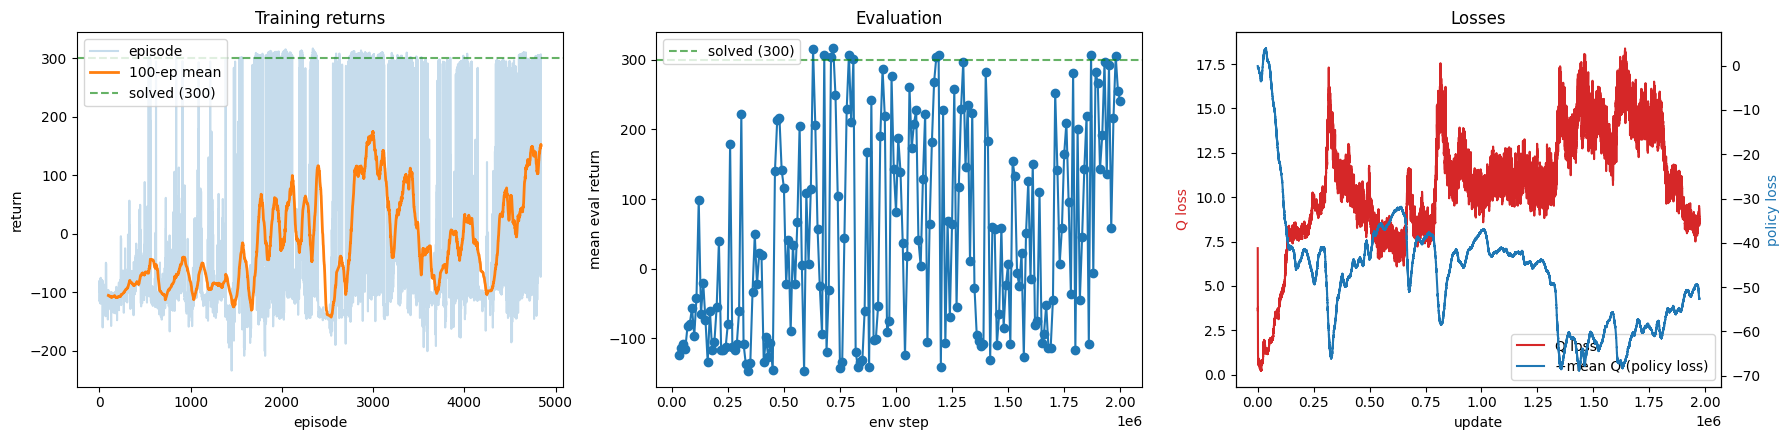

In [13]:
# ==================== Training curves ====================
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Episode returns + rolling mean
axes[0].plot(episode_returns, alpha=0.25, label="episode")
if len(episode_returns) >= 50:
    w = min(100, len(episode_returns))
    smooth = np.convolve(episode_returns, np.ones(w) / w, mode="valid")
    axes[0].plot(range(w - 1, len(episode_returns)), smooth, label=f"{w}-ep mean", lw=2)
axes[0].axhline(300, color="g", ls="--", alpha=0.6, label="solved (300)")
axes[0].set_xlabel("episode"); axes[0].set_ylabel("return")
axes[0].set_title("Training returns"); axes[0].legend()

# Eval returns
if eval_returns:
    steps_e, rets_e = zip(*eval_returns)
    axes[1].plot(steps_e, rets_e, "o-")
    axes[1].axhline(300, color="g", ls="--", alpha=0.6, label="solved (300)")
    axes[1].set_xlabel("env step"); axes[1].set_ylabel("mean eval return")
    axes[1].set_title("Evaluation"); axes[1].legend()

# Losses
if q_loss_hist:
    w = min(1000, len(q_loss_hist))
    q_smooth = np.convolve(q_loss_hist, np.ones(w) / w, mode="valid")
    p_smooth = np.convolve(p_loss_hist, np.ones(w) / w, mode="valid")
    ax2b = axes[2].twinx()
    l1 = axes[2].plot(q_smooth, color="tab:red",  label="Q loss")
    l2 = ax2b.plot   (p_smooth, color="tab:blue", label="−mean Q (policy loss)")
    axes[2].set_xlabel("update"); axes[2].set_ylabel("Q loss", color="tab:red")
    ax2b.set_ylabel("policy loss", color="tab:blue")
    axes[2].set_title("Losses")
    axes[2].legend(l1 + l2, [l.get_label() for l in l1 + l2])

plt.tight_layout(); plt.show()


# Testing

Test the model on the environment and get a cool video.

In [ ]:
# If rendering deps are missing, uncomment and run:
# %pip install "gymnasium[box2d,other]" moviepy


In [14]:
# ==================== Reload the best checkpoint ====================
best_path = os.path.join(SAVE_DIR, "policy_best.keras")
if os.path.exists(best_path):
    policy_model = keras.models.load_model(best_path, safe_mode=False)
    print(f"Loaded best policy from {best_path}")
else:
    print(f"WARNING: {best_path} not found — using current in-memory policy.")

# Sanity check: one deterministic episode without rendering.
sanity_env = gym.make("BipedalWalker-v3")
obs, _ = sanity_env.reset(seed=123)
total_r, done = 0.0, False
while not done:
    a = policy_model(np.expand_dims(obs, 0).astype(np.float32), training=False).numpy()[0]
    a = np.clip(a, act_low, act_high)
    obs, r, term, trunc, _ = sanity_env.step(a)
    total_r += r
    done = term or trunc
sanity_env.close()
print(f"Sanity-check return: {total_r:.2f}")


Loaded best policy from best_model_2\policy_best.keras
Sanity-check return: 315.86


In [15]:
# ==================== Record videos ====================
from gymnasium.wrappers import RecordVideo

VIDEO_DIR = "./videos"
os.makedirs(VIDEO_DIR, exist_ok=True)

test_env = gym.make("BipedalWalker-v3", render_mode="rgb_array")
test_env = RecordVideo(
    test_env,
    video_folder=VIDEO_DIR,
    name_prefix="ddpg_bipedal",
    episode_trigger=lambda ep_id: True,  # record every episode
)

N_TEST_EPISODES = 5
test_returns = []
for ep in range(N_TEST_EPISODES):
    obs, _ = test_env.reset(seed=1000 + ep)
    ep_ret, done = 0.0, False
    while not done:
        a = policy_model(np.expand_dims(obs, 0).astype(np.float32), training=False).numpy()[0]
        a = np.clip(a, act_low, act_high)
        obs, r, term, trunc, _ = test_env.step(a)
        ep_ret += r
        done = term or trunc
    test_returns.append(ep_ret)
    print(f"Test episode {ep + 1}: return = {ep_ret:.2f}")

test_env.close()
print(f"\nMean test return: {np.mean(test_returns):.2f} ± {np.std(test_returns):.2f}")
print(f"Videos saved to: {os.path.abspath(VIDEO_DIR)}")


C:\Users\maxim\anaconda3\envs\ocrlab\lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at C:\Users\maxim\RL\2\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Test episode 1: return = 91.22
Test episode 2: return = 5.49
Test episode 3: return = -4.45
Test episode 4: return = 44.19
Test episode 5: return = 318.07

Mean test return: 90.90 ± 118.47
Videos saved to: C:\Users\maxim\RL\2\videos


In [16]:
# ==================== Show the best video inline ====================
import glob
from IPython.display import Video

videos = sorted(glob.glob(os.path.join(VIDEO_DIR, "*.mp4")))
if not videos:
    print("No videos found.")
else:
    # Pick the episode with the highest return.
    best_idx = int(np.argmax(test_returns))
    print(f"Showing episode {best_idx + 1} (return={test_returns[best_idx]:.2f})")
    display_path = videos[best_idx] if best_idx < len(videos) else videos[0]
    Video(display_path, embed=True, width=640)


Showing episode 5 (return=318.07)
